# Quantum Kernel SVM

Binary classification on the Iris dataset using a Support Vector Machine whose kernel
matrix is computed by a quantum circuit.

Results are saved to `qksvm_results.json` for use in `comparison/comparison.ipynb`.

---

## How a Quantum Kernel SVM works

A classical SVM with a custom kernel works in two steps:

1. **Compute the kernel matrix** `K[i,j] = k(x_i, x_j)` for every pair of training points.
   This matrix encodes how similar each pair of points is in the feature space induced by the kernel.
2. **Train the SVM** using that matrix. The SVM optimizer only ever sees `K`, never the raw data.

In the Quantum Kernel SVM, step 1 is replaced by a quantum circuit:

- Each data point `x` is encoded into a quantum state `|φ(x)⟩` using a **feature map circuit**.
- The kernel value between two points is the squared overlap (fidelity) of their quantum states:
  `k(x_i, x_j) = |⟨φ(x_i)|φ(x_j)⟩|²`
- This is estimated by running a circuit that prepares `|φ(x_i)⟩`, then applies the inverse
  of the circuit for `|φ(x_j)⟩`, and measures the probability of the all-zeros outcome `|0...0⟩`.

Step 2 is entirely classical — the SVM is trained on the quantum kernel matrix exactly as it
would be trained on an RBF kernel matrix.

**Key difference from VQC:** the quantum circuit has no trainable parameters.
There is no gradient descent. The circuit is fixed; only the SVM is trained.

---

**Configuration variable:** `N_FEATURES` controls how many features (and qubits) are used.  
**Hardware:** Kernel computation runs on the Aer simulator. Set `RUN_ON_REAL_HW = True`
to recompute the test kernel matrix on IBM Quantum hardware.

## Imports

In [2]:
import time
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import BackendSamplerV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.kernels import TrainableFidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute

## Configuration

In [ ]:
N_FEATURES     = 2       # 2 or 4 — must match svm.ipynb
TEST_SIZE      = 0.2     # must match svm.ipynb
RANDOM_SEED    = 42      # must match svm.ipynb
RUN_ON_REAL_HW = False   # set True to recompute test kernel on IBM Quantum

RESULTS_FILE = "qksvm_results.json" if N_FEATURES == 2 else "qksvm_results_4f.json"

print(f"Configuration: N_FEATURES={N_FEATURES}, RUN_ON_REAL_HW={RUN_ON_REAL_HW}")
print(f"Results will be saved to: {RESULTS_FILE}")


## Dataset

Identical preprocessing to `svm.ipynb` — same seed, same split, same scaling.
Features are scaled to [0, π] so they span the full rotation range of the feature map gates.

In [4]:
iris = load_iris()

mask   = iris.target != 0
X_full = iris.data[mask]
y_full = iris.target[mask] - 1

if N_FEATURES == 2:
    X = X_full[:, 2:4]
    feature_names = ["petal length", "petal width"]
else:
    X = X_full
    feature_names = list(iris.feature_names)

scaler      = MinMaxScaler()
X_scaled    = scaler.fit_transform(X)
X_scaled_pi = X_scaled * np.pi   # scale to [0, π] for rotation gates

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_pi, y_full, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_full
)

print(f"Total samples : {len(X_scaled_pi)}")
print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")
print(f"Features used : {feature_names}")

Total samples : 100
Train samples : 80
Test samples  : 20
Features used : ['petal length', 'petal width']


## Quantum Kernel — Feature Map

We use `ZZFeatureMap` with `reps=2`, the same circuit used in the VQC experiment.
This makes the two quantum experiments directly comparable in terms of circuit structure.

The kernel value `k(x_i, x_j)` is estimated as the probability of measuring `|0...0⟩`
after running the circuit `U(x_j)† U(x_i)`, where `U(x)` is the feature map applied to `x`.
A value close to 1 means the two points map to very similar quantum states (high similarity);
a value close to 0 means they are nearly orthogonal in the quantum feature space (low similarity).

Number of qubits : 2
Feature map      : ZZFeatureMap (reps=2)
Trainable params : 0  (kernel is fixed — no gradient descent)


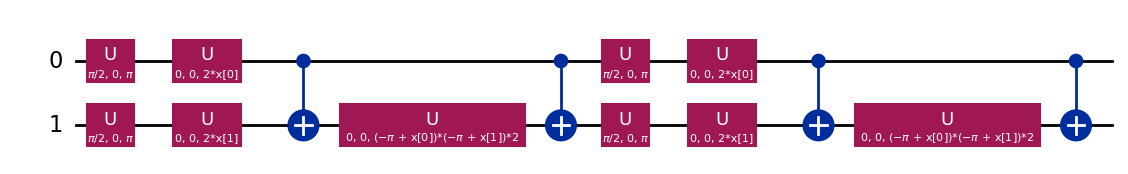

In [5]:
n_qubits    = N_FEATURES
feature_map = zz_feature_map(feature_dimension=n_qubits, reps=2)

print(f"Number of qubits : {n_qubits}")
print(f"Feature map      : ZZFeatureMap (reps=2)")
print(f"Trainable params : 0  (kernel is fixed — no gradient descent)")
feature_map.decompose().draw(output="mpl", fold=-1)

## Compute Kernel Matrices on Aer Simulator

We need two kernel matrices:
- **Train kernel** `K_train[i,j] = k(x_train_i, x_train_j)` — used to fit the SVM.
- **Test kernel**  `K_test[i,j]  = k(x_test_i,  x_train_j)` — used to predict.

For `n_train` training points, the train kernel requires `n_train*(n_train+1)/2` circuit
evaluations (symmetric matrix). The test kernel requires `n_test * n_train` evaluations.
This is the main computational cost of the QKSVM.

Note: `FidelityQuantumKernel` handles the circuit construction and evaluation automatically.

In [6]:
backend  = AerSimulator()
pm       = generate_preset_pass_manager(backend=backend, optimization_level=1)
sampler  = BackendSamplerV2(backend=backend)
fidelity = ComputeUncompute(sampler=sampler, pass_manager=pm)

quantum_kernel = FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelity)

print("Computing train kernel matrix...")
t0 = time.perf_counter()
K_train = quantum_kernel.evaluate(x_vec=X_train)
kernel_train_time = time.perf_counter() - t0
print(f"  Done in {kernel_train_time:.2f} s  — shape: {K_train.shape}")

print("Computing test kernel matrix...")
t0 = time.perf_counter()
K_test = quantum_kernel.evaluate(x_vec=X_test, y_vec=X_train)
kernel_test_time = time.perf_counter() - t0
print(f"  Done in {kernel_test_time:.2f} s  — shape: {K_test.shape}")

total_kernel_time = kernel_train_time + kernel_test_time
print(f"\nTotal kernel computation time: {total_kernel_time:.2f} s")

Computing train kernel matrix...
  Done in 10.48 s  — shape: (80, 80)
Computing test kernel matrix...
  Done in 5.05 s  — shape: (20, 80)

Total kernel computation time: 15.53 s


## Train SVM on Quantum Kernel

We pass the precomputed kernel matrix directly to the SVM using `kernel='precomputed'`.
The SVM then treats `K_train` as its gram matrix and optimizes the support vectors
and decision boundary — fully classical step.

In [7]:
qksvm = SVC(kernel="precomputed", C=1.0, random_state=RANDOM_SEED)

t0 = time.perf_counter()
qksvm.fit(K_train, y_train)
svm_train_time = time.perf_counter() - t0

print(f"SVM training time (on quantum kernel): {svm_train_time:.4f} s")
print(f"Number of support vectors: {sum(qksvm.n_support_)}")

SVM training time (on quantum kernel): 0.0026 s
Number of support vectors: 48


## Evaluation on Simulator

In [8]:
y_pred_train_sim = qksvm.predict(K_train)
y_pred_test_sim  = qksvm.predict(K_test)

acc_train_sim = accuracy_score(y_train, y_pred_train_sim)
acc_test_sim  = accuracy_score(y_test,  y_pred_test_sim)

print(f"Train accuracy (simulator): {acc_train_sim:.4f}")
print(f"Test accuracy  (simulator): {acc_test_sim:.4f}")
print()
print(classification_report(y_test, y_pred_test_sim,
                             target_names=["Versicolor", "Virginica"]))

Train accuracy (simulator): 0.8250
Test accuracy  (simulator): 0.6500

              precision    recall  f1-score   support

  Versicolor       0.67      0.60      0.63        10
   Virginica       0.64      0.70      0.67        10

    accuracy                           0.65        20
   macro avg       0.65      0.65      0.65        20
weighted avg       0.65      0.65      0.65        20



## Evaluation on IBM Quantum Hardware (optional)

Only the **test kernel matrix** is recomputed on real hardware. The SVM was already
trained on the simulator kernel — we only want to see how hardware noise affects
the kernel values and, consequently, the predictions.

Set `RUN_ON_REAL_HW = True` in the Configuration cell to enable this section.

In [9]:
acc_test_real    = None
y_pred_test_real = None
backend_name     = None
kernel_real_time = None

if RUN_ON_REAL_HW:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RealSampler

    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False,
                                  min_num_qubits=n_qubits)
    backend_name = backend.name
    print(f"Using backend: {backend_name}")

    real_pm       = generate_preset_pass_manager(backend=backend, optimization_level=1)
    real_sampler  = RealSampler(backend)
    real_fidelity = ComputeUncompute(sampler=real_sampler, pass_manager=real_pm)

    # max_circuits_per_job splits the 1600 kernel pairs into small batches so each
    # IBM job stays within the free-plan per-job time limit (error 1305).
    quantum_kernel_real = FidelityQuantumKernel(
        feature_map=feature_map,
        fidelity=real_fidelity,
        max_circuits_per_job=50,
    )

    print("Computing test kernel matrix on real hardware (batched, 50 circuits/job)...")
    t0 = time.perf_counter()
    K_test_real      = quantum_kernel_real.evaluate(x_vec=X_test, y_vec=X_train)
    kernel_real_time = time.perf_counter() - t0
    print(f"  Done in {kernel_real_time:.2f} s  — shape: {K_test_real.shape}")

    y_pred_test_real = qksvm.predict(K_test_real)
    acc_test_real    = accuracy_score(y_test, y_pred_test_real)
    print(f"Test accuracy (real HW): {acc_test_real:.4f}")
else:
    print("RUN_ON_REAL_HW is False — skipping real hardware evaluation.")
    print("Set RUN_ON_REAL_HW = True in the Configuration cell to enable.")


Using backend: ibm_marrakesh
Computing test kernel matrix on real hardware (batched, 50 circuits/job)...


/home/david/Desktop/TFG/Qiskit/.venv/lib/python3.12/site-packages/qiskit_ibm_runtime/qiskit_runtime_service.py:1200: UserWarning: This instance has met its usage limit. Workloads will not run until time is made available. Check https://quantum.cloud.ibm.com/instances/crn%3Av1%3Abluemix%3Apublic%3Aquantum-computing%3Aus-east%3Aa%2F1590966eb39c427db4084e92df105f61%3A6cc9354c-ef78-4192-9134-fe68c70ba27d%3A%3A for more details.
  warnings.warn(


KeyboardInterrupt: 

## Plots

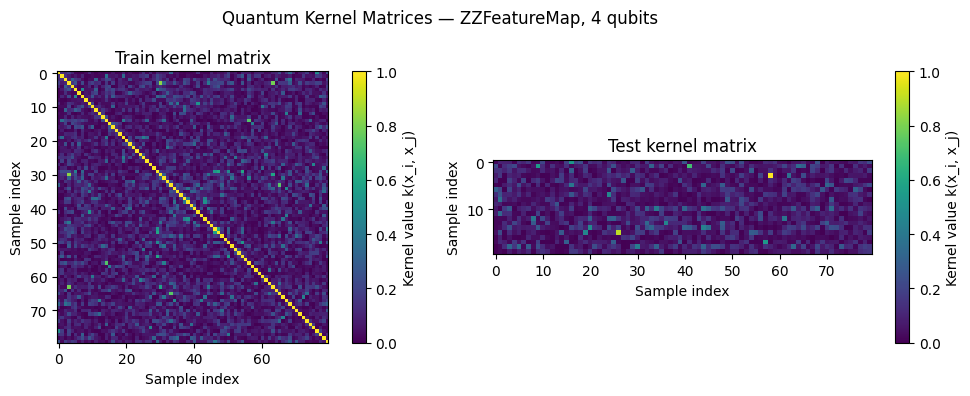

In [ ]:
# --- Kernel matrix heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, matrix, title in zip(axes,
                               [K_train, K_test],
                               ["Train kernel matrix", "Test kernel matrix"]):
    im = ax.imshow(matrix, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Sample index")
    ax.set_ylabel("Sample index")
    plt.colorbar(im, ax=ax, label="Kernel value k(x_i, x_j)")

plt.suptitle(f"Quantum Kernel Matrices — ZZFeatureMap, {n_qubits} qubits")
plt.tight_layout()
plt.savefig(f"qksvm_kernel_matrices{'_4f' if N_FEATURES == 4 else ''}.png", dpi=150)
plt.show()

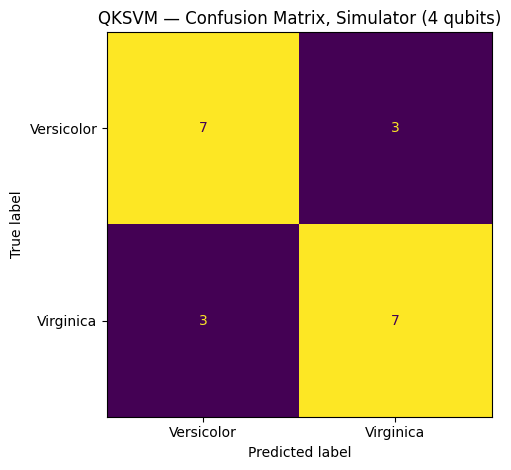

In [ ]:
# --- Confusion matrix ---
cm   = confusion_matrix(y_test, y_pred_test_sim)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Versicolor", "Virginica"])
disp.plot(colorbar=False)
plt.title(f"QKSVM — Confusion Matrix, Simulator ({N_FEATURES} qubits)")
plt.tight_layout()
plt.savefig(f"qksvm_confusion_matrix_sim{'_4f' if N_FEATURES == 4 else ''}.png", dpi=150)
plt.show()

In [ ]:
# --- Decision boundary (only for 2 features) ---
if N_FEATURES == 2:
    h = 0.20   # coarser grid — quantum kernel evaluation is O(n_grid * n_train) circuits
    xx, yy  = np.meshgrid(np.arange(0, np.pi + h, h), np.arange(0, np.pi + h, h))
    grid    = np.c_[xx.ravel(), yy.ravel()]

    # Kernel between grid points and training points
    K_grid  = quantum_kernel.evaluate(x_vec=grid, y_vec=X_train)
    Z       = qksvm.predict(K_grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
                          cmap="coolwarm", edgecolors="k", s=40, label="Train")
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test,
                cmap="coolwarm", edgecolors="r", s=60, marker="^", label="Test")
    plt.colorbar(scatter, ticks=[0, 1], label="Class")
    plt.xlabel("petal length (scaled × π)")
    plt.ylabel("petal width  (scaled × π)")
    plt.title("QKSVM — Decision Boundary (2 qubits, Aer simulator)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("qksvm_decision_boundary.png", dpi=150)
    plt.show()
else:
    print("Decision boundary plot skipped (only available for N_FEATURES=2).")

Decision boundary plot skipped (only available for N_FEATURES=2).


## Save Results

In [ ]:
results = {
    # --- Experiment metadata ---
    "model"                 : "QKSVM",
    "n_features"            : N_FEATURES,
    "n_qubits"              : n_qubits,
    "feature_names"         : feature_names,
    "n_train"               : int(len(X_train)),
    "n_test"                : int(len(X_test)),
    "random_seed"           : RANDOM_SEED,
    # --- Circuit architecture ---
    "feature_map"           : "ZZFeatureMap",
    "feature_map_reps"      : 2,
    "n_trainable_params"    : 0,
    # --- Timing ---
    "kernel_train_time_s"   : float(kernel_train_time),
    "kernel_test_time_s"    : float(kernel_test_time),
    "total_kernel_time_s"   : float(total_kernel_time),
    "svm_train_time_s"      : float(svm_train_time),
    "total_time_s"          : float(total_kernel_time + svm_train_time),
    # --- Accuracy (simulator) ---
    "accuracy_test_sim"     : float(acc_test_sim),
    "accuracy_train_sim"    : float(acc_train_sim),
    # --- SVM details ---
    "n_support_vectors"     : int(sum(qksvm.n_support_)),
    "svm_C"                 : qksvm.C,
    # --- Predictions (simulator) ---
    "y_test"                : y_test.tolist(),
    "y_pred_test_sim"       : y_pred_test_sim.tolist(),
    # --- Real hardware ---
    "real_hw_run"           : RUN_ON_REAL_HW,
    "backend_name"          : backend_name,
    "accuracy_test_real"    : float(acc_test_real) if acc_test_real is not None else None,
    "kernel_real_time_s"    : float(kernel_real_time) if kernel_real_time is not None else None,
    "y_pred_test_real"      : y_pred_test_real.tolist() if y_pred_test_real is not None else None,
}

with open(RESULTS_FILE, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {RESULTS_FILE}")
summary_keys = [k for k in results if k not in ("y_test", "y_pred_test_sim", "y_pred_test_real")]
print(json.dumps({k: results[k] for k in summary_keys}, indent=2))

Results saved to qksvm_results_4f.json
{
  "model": "QKSVM",
  "n_features": 4,
  "n_qubits": 4,
  "feature_names": [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
  ],
  "n_train": 80,
  "n_test": 20,
  "random_seed": 42,
  "feature_map": "ZZFeatureMap",
  "feature_map_reps": 2,
  "n_trainable_params": 0,
  "kernel_train_time_s": 15.621025136999378,
  "kernel_test_time_s": 7.627234147999843,
  "total_kernel_time_s": 23.24825928499922,
  "svm_train_time_s": 0.0018180750012106728,
  "total_time_s": 23.250077360000432,
  "accuracy_test_sim": 0.7,
  "accuracy_train_sim": 0.9625,
  "n_support_vectors": 74,
  "svm_C": 1.0,
  "real_hw_run": false,
  "backend_name": null,
  "accuracy_test_real": null,
  "kernel_real_time_s": null
}
